## One Tight One Loose

In [1]:
%cd ..

/eos/home-i00/d/driosper/bsm3g_coffea


In [2]:
from coffea.util import load
import numpy as np
import mplhep as hep
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
from coffea.processor import accumulate
from hist.intervals import poisson_interval
from pathlib import Path
import yaml
from analysis.filesets.utils import get_process_maps
from analysis.workflows.config import WorkflowConfigBuilder
import json
year = "2017"
out = load(f"outputs/qcd_tf_ele/{year}/{year}_processed_histograms.coffea")

In [3]:
config_builder = WorkflowConfigBuilder(workflow="qcd_tf_ele")
workflow_config = config_builder.build_workflow_config()
postprocess_dir = Path.cwd() / "analysis" / "postprocess"
style_file = postprocess_dir / "style.yaml"
luminosity_file = postprocess_dir / "luminosity.yaml"
color_map_file = postprocess_dir / "color_map.yaml"

with open(style_file, "r") as f:
    style = yaml.safe_load(f)
with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)

# set processes -> color and processes -> sample name maps
processes, process_name_map, _ = get_process_maps(workflow_config, year)
with open(color_map_file, "r") as f:
    color_map = yaml.safe_load(f)
color_map = {p: c for p, c in color_map.items() if p in processes}

hep.style.use(hep.style.CMS)
plt.rcParams.update(style["rcParams"])

In [4]:
year = "2017"
out = load(f"outputs/qcd_tf_ele/{year}/{year}_processed_histograms.coffea")
data = out["Data"]["transverse_mass"][{"variation": "nominal"}]

mc = accumulate([
    out["DYJetsToLL"]["transverse_mass"][{"variation": "nominal"}],
    out["SingleTop"]["transverse_mass"][{"variation": "nominal"}],
    out["tt"]["transverse_mass"][{"variation": "nominal"}],
    out["Diboson"]["transverse_mass"][{"variation": "nominal"}]
])

histo = data + (mc * -1)

variable = "electron_met_mass_leading"

h_loose = histo[{"category": "1LnT1nT"}].project(variable)
h_tight = histo[{"category": "1LnT1T"}].project(variable)

num = h_tight.values()
den = h_loose.values()

var_num = h_tight.variances()
var_den = h_loose.variances()

tf = np.where(
    (num > 0) & (den > 0), 
    num / (den + 1e-32),
    1
)

tf_var = np.zeros_like(tf)

mask = den != 0

tf_var[mask] = (
    (1.0 / den[mask])**2 * var_num[mask]
    +
    (num[mask] / den[mask]**2)**2 * var_den[mask]
)

h_tf = h_loose.copy()
h_tf.values()[:] = tf
h_tf.variances()[:] = tf_var

h_loose_not_tight = histo[{"category": "1LnT1nT"}].project(variable)
h_qcd = h_loose_not_tight * tf
print(histo[{"category": "1LnT1T"}].project(variable).values())

[130.55402988 183.93459329 323.79801853 509.25624272 286.99822496
 121.36128825 108.24552394  48.35646535  45.70250275]


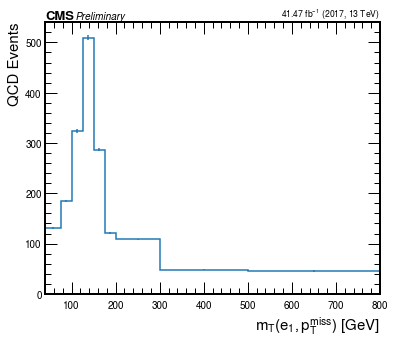

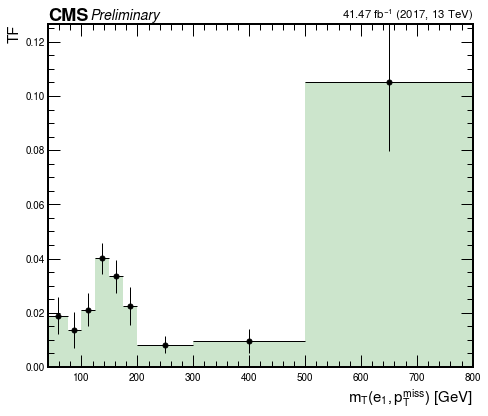

In [5]:
def plot_cms_tf(hist_histogram):
    hep.style.use(hep.style.CMS)

    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 15,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.markersize": 2,
        "legend.fontsize": 10,
    })

    fig, ax = plt.subplots(figsize=(7, 6))

    edges = hist_histogram.axes[0].edges
    values = hist_histogram.values()
    variances = hist_histogram.variances()

    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    errors = np.sqrt(variances)

    ax.bar(
        centers,
        values,
        width=widths,
        align="center",
        alpha=0.2,
        color="green",
        edgecolor=None
    )

    for i in range(len(values)):
        ax.hlines(
            values[i],
            edges[i],
            edges[i+1],
            colors="black",
            linewidth=1
        )

    ax.errorbar(
        centers,
        values,
        yerr=errors,
        fmt='o',
        color='black',
        markersize=5,
        capsize=0,
        linewidth=1
    )

    ax.set_ylabel("TF")
    ax.set_xlabel(r"$m_T(e_1, p_T^{miss})$ [GeV]")

    ax.set_ylim(0, np.max(values) * 1.2)
    ax.set_xlim(edges[0], edges[-1])

    ax.tick_params(direction="in", top=True, right=True)

    hep.cms.lumitext("41.47 fb$^{-1}$ (2017, 13 TeV)", fontsize=12, ax=ax)
    hep.cms.text("Preliminary", loc=0, ax=ax)

    plt.tight_layout()
    plt.savefig("qcd_tf.png")
    plt.show()
def plot_cms_histogram(hist_histogram, variable):
    import mplhep as hep
    hep.style.use(hep.style.CMS)
    plt.rcParams.update(
        {
            "font.size": 14,
            "axes.titlesize": 14,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "lines.markersize": 4,
            "legend.fontsize": 10,
        }
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    hist_histogram.project(variable).plot1d(ax=ax)
    ax.set(ylabel="QCD Events")
    edges = hist_histogram.axes[0].edges
    ax.set_xlim(edges[0], edges[-1])
    hep.cms.lumitext("41.47 fb$^{-1}$ (2017, 13 TeV)", fontsize=9, ax=ax)
    hep.cms.text("Preliminary", loc=0, ax=ax)
    plt.savefig("qcd.png")
    
plot_cms_histogram(h_qcd, variable)
plot_cms_tf(h_tf)